# 🚀 Space Defender - PRO MODE v7: Clean Slate
## Simplified Rewards + Prioritized Experience Replay + Dueling DQN

**Target: 3500 ± 300 consistent score**

---

### Problem Analysis from v4-v6:
- Agent optimizes reward shaping instead of winning
- Complex rewards create local optima
- Best single games (5100) show potential exists
- Longer training = worse (overfitting to shaped rewards)

### v7 Philosophy: "Kill enemies. Don't die. Figure out the rest."

---

### Key Changes:

| Component | v5/v6 | v7 |
|-----------|-------|----|
| **Rewards** | 15+ signals | **3 signals only** |
| **Replay** | Uniform random | **Prioritized (PER)** |
| **Architecture** | MLP with dropout | **Dueling DQN** |
| **Training** | Fine-tune v4 | **From scratch** |
| **Evaluation** | 10 games | **5 games** |

### v7 Reward Structure (SIMPLE):
```
+0.01  per frame survived (tiny baseline)
+10    hit enemy
+50    kill enemy (MAIN OBJECTIVE)
-30    take damage
-100   die (MAIN PENALTY)
```

**That's it. No positioning rewards. No escape bonuses. No camping penalties.**

Let the agent learn positioning from experience, not from hand-crafted signals.

---
## 📌 Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from datetime import datetime

# =========================
# CONFIGURE YOUR PATHS HERE
# =========================
PROJECT_NAME = "Assignment 1 v1 A100 - Zhou Bojian"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

# v7: Training from scratch - no checkpoint needed
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"{BASE_DIR}/v7_simplified_PER_{TIMESTAMP}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/models", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/videos", exist_ok=True)

print(f"📂 Output directory: {OUTPUT_DIR}")
print(f"")
print(f"🔴 v7: Training from SCRATCH with simplified rewards")
print(f"   No checkpoint loading - clean slate!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Output directory: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/v7_simplified_PER_20260118_055120

🔴 v7: Training from SCRATCH with simplified rewards
   No checkpoint loading - clean slate!


---
## 📌 Step 2: Install Dependencies

In [ ]:
!pip install pygame -q
!apt-get install -y xvfb ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay imageio[ffmpeg] -q
!pip install sympy==1.12.1 --quiet

import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import imageio
import json

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"✅ All packages installed!")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Random seed: {SEED}")

✅ All packages installed!
PyTorch: 2.9.0+cu126 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
Random seed: 42


---
## 📌 Step 3: Configuration

Tuned for training from scratch with longer horizon.

In [ ]:
class Config:
    # Game dimensions
    SCREEN_WIDTH = 600
    SCREEN_HEIGHT = 800

    # Player settings
    PLAYER_WIDTH = 50
    PLAYER_HEIGHT = 40
    PLAYER_SPEED = 8
    PLAYER_BULLET_SPEED = 12
    PLAYER_SHOOT_COOLDOWN = 15
    PLAYER_MAX_HEALTH = 3

    # Enemy settings
    ENEMY_WIDTH = 40
    ENEMY_HEIGHT = 35
    ENEMY_SPEED = 3
    ENEMY_BULLET_SPEED = 6
    ENEMY_SPAWN_RATE = 60
    MAX_ENEMIES = 8
    ENEMY_SHOOT_CHANCE = 0.02

    # ================================================================
    # v7 HYPERPARAMETERS - Tuned for training from scratch
    # ================================================================
    LEARNING_RATE = 0.0001        # Higher for fresh training
    DISCOUNT_FACTOR = 0.99
    EPSILON_START = 1.0           # Full exploration at start
    EPSILON_MIN = 0.02            # Small minimum for some exploration
    EPSILON_DECAY = 0.9995        # Slow decay for thorough exploration
    BATCH_SIZE = 128              # Smaller batch, more updates
    MEMORY_SIZE = 200000          # Large replay buffer
    TARGET_UPDATE = 500           # Less frequent hard updates

    # Prioritized Experience Replay
    PER_ALPHA = 0.6               # Priority exponent (0=uniform, 1=full priority)
    PER_BETA_START = 0.4          # Importance sampling start
    PER_BETA_END = 1.0            # Importance sampling end
    PER_EPSILON = 1e-6            # Small constant to avoid zero priority

    # State: 22 features × 4 frames = 88
    STATE_SIZE = 88
    ACTION_SIZE = 6

print("="*60)
print("✅ Config loaded (v7 - Simplified Rewards + PER)")
print("="*60)
print(f"")
print(f"🔴 v7 KEY SETTINGS:")
print(f"   Learning Rate: {Config.LEARNING_RATE}")
print(f"   Starting ε: {Config.EPSILON_START} (full exploration)")
print(f"   ε decay: {Config.EPSILON_DECAY}")
print(f"   ε min: {Config.EPSILON_MIN}")
print(f"   Memory Size: {Config.MEMORY_SIZE}")
print(f"   PER α: {Config.PER_ALPHA}")
print(f"   PER β: {Config.PER_BETA_START} → {Config.PER_BETA_END}")

✅ Config loaded (v7 - Simplified Rewards + PER)

🔴 v7 KEY SETTINGS:
   Learning Rate: 0.0001
   Starting ε: 1.0 (full exploration)
   ε decay: 0.9995
   ε min: 0.02
   Memory Size: 200000
   PER α: 0.6
   PER β: 0.4 → 1.0


---
## 📌 Step 4: Game Objects

In [ ]:
class Player:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.PLAYER_WIDTH, Config.PLAYER_HEIGHT
        self.speed = Config.PLAYER_SPEED
        self.health = Config.PLAYER_MAX_HEALTH
        self.shoot_cooldown = 0
        self.score = 0
        self.alive = True

    def move(self, direction):
        self.x = max(0, min(self.x + direction * self.speed, Config.SCREEN_WIDTH - self.width))

    def update(self):
        if self.shoot_cooldown > 0: self.shoot_cooldown -= 1

    def can_shoot(self): return self.shoot_cooldown == 0

    def shoot(self):
        self.shoot_cooldown = Config.PLAYER_SHOOT_COOLDOWN
        return Bullet(self.x + self.width // 2 - 3, self.y - 15, -Config.PLAYER_BULLET_SPEED, True)

    def take_damage(self):
        self.health -= 1
        if self.health <= 0: self.alive = False


class Enemy:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.ENEMY_WIDTH, Config.ENEMY_HEIGHT
        self.speed = Config.ENEMY_SPEED + random.uniform(-1, 1)
        self.health, self.alive = 1, True
        self.direction = random.choice([-1, 0, 1])
        self.change_dir_timer = random.randint(30, 90)

    def update(self):
        self.y += self.speed
        self.x = max(0, min(self.x + self.direction * 2, Config.SCREEN_WIDTH - self.width))
        self.change_dir_timer -= 1
        if self.change_dir_timer <= 0:
            self.direction = random.choice([-1, 0, 1])
            self.change_dir_timer = random.randint(30, 90)
        if self.y > Config.SCREEN_HEIGHT: self.alive = False

    def should_shoot(self): return random.random() < Config.ENEMY_SHOOT_CHANCE

    def shoot(self):
        return Bullet(self.x + self.width // 2 - 3, self.y + self.height, Config.ENEMY_BULLET_SPEED, False)


class Bullet:
    def __init__(self, x, y, speed, is_player_bullet):
        self.x, self.y, self.speed = x, y, speed
        self.width, self.height = 6, 15
        self.is_player_bullet = is_player_bullet
        self.alive = True

    def update(self):
        self.y += self.speed
        if self.y < -self.height or self.y > Config.SCREEN_HEIGHT: self.alive = False

print("✅ Game objects defined!")

✅ Game objects defined!


---
## 📌 Step 5: Dueling DQN Architecture

In [ ]:
class DuelingDQN(nn.Module):
    """
    Dueling DQN Architecture

    Q(s,a) = V(s) + (A(s,a) - mean(A(s,:)))

    - Value stream: How good is this state overall?
    - Advantage stream: How much better is each action than average?
    """
    def __init__(self, input_size, output_size):
        super().__init__()

        # Shared feature extraction
        self.feature = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

        # Value stream: V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

        # Advantage stream: A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        features = self.feature(x)

        value = self.value_stream(features)
        advantage = self.advantage_stream(features)

        # Q = V + (A - mean(A))
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))

        return q_values


# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

test_model = DuelingDQN(Config.STATE_SIZE, Config.ACTION_SIZE)
print(f"✅ Dueling DQN defined!")
print(f"   Architecture: 88 → 512 → 512 → 256 → (V:128→1, A:128→6)")
print(f"   Total parameters: {count_parameters(test_model):,}")
del test_model

✅ Dueling DQN defined!
   Architecture: 88 → 512 → 512 → 256 → (V:128→1, A:128→6)
   Total parameters: 506,247


---
## 📌 Step 6: Prioritized Experience Replay (PER)

**Key Idea:** Learn more from important transitions (surprising outcomes, deaths, kills)

- Higher TD-error = more surprising = higher priority
- Deaths and kills get replayed more often
- Importance sampling corrects for the bias

In [ ]:
class SumTree:
    """
    Binary tree where each node is sum of children.
    Leaf nodes store priorities, enables O(log n) sampling.
    """
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = np.zeros(capacity, dtype=object)
        self.write_idx = 0
        self.n_entries = 0

    def _propagate(self, idx, change):
        parent = (idx - 1) // 2
        self.tree[parent] += change
        if parent != 0:
            self._propagate(parent, change)

    def _retrieve(self, idx, s):
        left = 2 * idx + 1
        right = left + 1

        if left >= len(self.tree):
            return idx

        if s <= self.tree[left]:
            return self._retrieve(left, s)
        else:
            return self._retrieve(right, s - self.tree[left])

    def total(self):
        return self.tree[0]

    def add(self, priority, data):
        idx = self.write_idx + self.capacity - 1

        self.data[self.write_idx] = data
        self.update(idx, priority)

        self.write_idx = (self.write_idx + 1) % self.capacity
        self.n_entries = min(self.n_entries + 1, self.capacity)

    def update(self, idx, priority):
        change = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, change)

    def get(self, s):
        idx = self._retrieve(0, s)
        data_idx = idx - self.capacity + 1
        return idx, self.tree[idx], self.data[data_idx]


class PrioritizedReplayMemory:
    """
    Prioritized Experience Replay buffer using SumTree.

    - Stores transitions with priorities based on TD-error
    - Samples transitions proportional to their priority
    - Uses importance sampling weights to correct bias
    """
    def __init__(self, capacity, alpha=0.6):
        self.tree = SumTree(capacity)
        self.capacity = capacity
        self.alpha = alpha  # Priority exponent
        self.max_priority = 1.0

    def push(self, state, action, reward, next_state, done):
        # New transitions get max priority (will be updated after training)
        priority = self.max_priority ** self.alpha
        self.tree.add(priority, (state, action, reward, next_state, done))

    def sample(self, batch_size, beta=0.4):
        """
        Sample batch with priorities.
        Returns: batch, indices, importance sampling weights
        """
        batch = []
        indices = []
        priorities = []

        segment = self.tree.total() / batch_size

        for i in range(batch_size):
            a = segment * i
            b = segment * (i + 1)
            s = random.uniform(a, b)

            idx, priority, data = self.tree.get(s)

            # Handle edge case of zero priority
            if data is None or (isinstance(data, int) and data == 0):
                # Resample
                s = random.uniform(0, self.tree.total())
                idx, priority, data = self.tree.get(s)

            batch.append(data)
            indices.append(idx)
            priorities.append(priority)

        # Compute importance sampling weights
        priorities = np.array(priorities) + Config.PER_EPSILON
        sampling_probs = priorities / self.tree.total()

        # Importance sampling weights: (N * P(i))^(-beta)
        weights = (self.tree.n_entries * sampling_probs) ** (-beta)
        weights = weights / weights.max()  # Normalize

        return batch, indices, weights

    def update_priorities(self, indices, td_errors):
        """
        Update priorities based on TD-errors.
        """
        for idx, td_error in zip(indices, td_errors):
            priority = (abs(td_error) + Config.PER_EPSILON) ** self.alpha
            self.tree.update(idx, priority)
            self.max_priority = max(self.max_priority, priority)

    def __len__(self):
        return self.tree.n_entries


print("✅ Prioritized Experience Replay defined!")
print(f"   α (priority exponent): {Config.PER_ALPHA}")
print(f"   β (importance sampling): {Config.PER_BETA_START} → {Config.PER_BETA_END}")

✅ Prioritized Experience Replay defined!
   α (priority exponent): 0.6
   β (importance sampling): 0.4 → 1.0


---
## 📌 Step 7: v7 Environment - SIMPLIFIED REWARDS

**The most important change in v7.**

Only 5 reward signals:
1. `+0.01` per frame survived
2. `+10` hit an enemy
3. `+50` kill an enemy
4. `-30` take damage
5. `-100` die

**No positioning rewards. No escape bonuses. Let the agent figure it out.**

In [ ]:
class SpaceDefenderEnv:
    """
    v7 Environment - SIMPLIFIED REWARDS

    Philosophy: "Kill enemies. Don't die. Figure out the rest."

    The agent must learn positioning from experience,
    not from hand-crafted reward signals.
    """

    def __init__(self):
        self.state_buffer = deque(maxlen=4)
        self.reset()

    def reset(self):
        self.player = Player(
            Config.SCREEN_WIDTH // 2 - Config.PLAYER_WIDTH // 2,
            Config.SCREEN_HEIGHT - 100
        )
        self.enemies = []
        self.player_bullets = []
        self.enemy_bullets = []

        self.frame_count = 0
        self.spawn_timer = 0
        self.game_over = False
        self.enemies_destroyed = 0
        self.survival_time = 0

        initial_frame = self._get_single_frame()
        for _ in range(4):
            self.state_buffer.append(initial_frame)

        return self._get_stacked_state()

    def _get_stacked_state(self):
        return np.concatenate(self.state_buffer)

    def _get_single_frame(self):
        state = []

        # Player info
        state.append(self.player.x / Config.SCREEN_WIDTH)
        state.append(1.0 if self.player.can_shoot() else 0.0)
        state.append(self.player.health / Config.PLAYER_MAX_HEALTH)

        # Nearest 3 enemies (sorted by distance)
        enemies_sorted = sorted(
            self.enemies,
            key=lambda e: abs(e.x - self.player.x) + abs(e.y - self.player.y)
        )[:3]

        for i in range(3):
            if i < len(enemies_sorted):
                enemy = enemies_sorted[i]
                rel_x = (enemy.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (enemy.y - self.player.y) / Config.SCREEN_HEIGHT
                threat = 1.0 if abs(enemy.x - self.player.x) < 100 else 0.0
                state.extend([rel_x, rel_y, threat])
            else:
                state.extend([0.0, -1.0, 0.0])

        # Nearest 5 enemy bullets (sorted by distance)
        bullets_sorted = sorted(
            self.enemy_bullets,
            key=lambda b: abs(b.x - self.player.x) + abs(b.y - self.player.y)
        )[:5]

        for i in range(5):
            if i < len(bullets_sorted):
                bullet = bullets_sorted[i]
                rel_x = (bullet.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (bullet.y - self.player.y) / Config.SCREEN_HEIGHT
                state.extend([rel_x, rel_y])
            else:
                state.extend([0.0, -1.0])

        return np.array(state, dtype=np.float32)

    def _check_collision(self, obj1, obj2):
        return (obj1.x < obj2.x + obj2.width and
                obj1.x + obj1.width > obj2.x and
                obj1.y < obj2.y + obj2.height and
                obj1.y + obj1.height > obj2.y)

    def step(self, action):
        self.frame_count += 1
        self.survival_time += 1

        # ================================================================
        # 🔴 v7: SIMPLIFIED REWARD - Only survival baseline
        # ================================================================
        reward = 0.01  # Tiny survival reward

        # Parse action
        move_dir = 0
        should_shoot = False

        if action == 0: move_dir = -1              # Left
        elif action == 1: move_dir = 1            # Right
        elif action == 2: move_dir = 0            # Stay
        elif action == 3: should_shoot = True     # Shoot only
        elif action == 4: move_dir = -1; should_shoot = True  # Left + Shoot
        elif action == 5: move_dir = 1; should_shoot = True   # Right + Shoot

        # Update player position
        self.player.move(move_dir)
        self.player.update()

        # ================================================================
        # 🔴 v7: NO POSITIONING REWARDS!
        # No edge penalty, no center bonus, no escape bonus, no camping penalty
        # ================================================================

        # Shooting
        if should_shoot and self.player.can_shoot():
            self.player_bullets.append(self.player.shoot())
            # No reward for shooting - only for hitting

        # Spawn enemies
        self.spawn_timer += 1
        if self.spawn_timer >= Config.ENEMY_SPAWN_RATE and len(self.enemies) < Config.MAX_ENEMIES:
            self.spawn_timer = 0
            spawn_x = random.randint(0, Config.SCREEN_WIDTH - Config.ENEMY_WIDTH)
            self.enemies.append(Enemy(spawn_x, -Config.ENEMY_HEIGHT))

        # Update enemies
        for enemy in self.enemies[:]:
            enemy.update()
            if enemy.should_shoot():
                self.enemy_bullets.append(enemy.shoot())
            if not enemy.alive:
                self.enemies.remove(enemy)
                # No penalty for enemies escaping - focus on kills

        # Update bullets
        for bullet in self.player_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.player_bullets.remove(bullet)

        for bullet in self.enemy_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.enemy_bullets.remove(bullet)

        # ================================================================
        # PLAYER BULLETS VS ENEMIES
        # ================================================================
        for bullet in self.player_bullets[:]:
            for enemy in self.enemies[:]:
                if self._check_collision(bullet, enemy):
                    bullet.alive = False
                    enemy.health -= 1

                    # 🔴 v7: Hit reward
                    reward += 10

                    if enemy.health <= 0:
                        enemy.alive = False
                        self.enemies.remove(enemy)
                        self.enemies_destroyed += 1
                        self.player.score += 100

                        # 🔴 v7: Kill reward (MAIN OBJECTIVE)
                        reward += 50

                    if bullet in self.player_bullets:
                        self.player_bullets.remove(bullet)
                    break

        # ================================================================
        # ENEMY BULLETS VS PLAYER
        # ================================================================
        for bullet in self.enemy_bullets[:]:
            if self._check_collision(bullet, self.player):
                bullet.alive = False
                self.enemy_bullets.remove(bullet)
                self.player.take_damage()

                # 🔴 v7: Damage penalty
                reward -= 30

                if not self.player.alive:
                    self.game_over = True
                    # 🔴 v7: Death penalty (MAIN PENALTY)
                    reward -= 100

        # ================================================================
        # ENEMY COLLISION WITH PLAYER
        # ================================================================
        for enemy in self.enemies[:]:
            if self._check_collision(enemy, self.player):
                enemy.alive = False
                self.enemies.remove(enemy)
                self.player.take_damage()

                # 🔴 v7: Collision damage penalty
                reward -= 30

                if not self.player.alive:
                    self.game_over = True
                    # 🔴 v7: Death penalty
                    reward -= 100

        done = self.game_over
        info = {
            'score': self.player.score,
            'enemies_destroyed': self.enemies_destroyed,
            'survival_time': self.survival_time,
            'health': self.player.health
        }

        self.state_buffer.append(self._get_single_frame())

        return self._get_stacked_state(), reward, done, info


print("="*60)
print("✅ v7 Environment - SIMPLIFIED REWARDS")
print("="*60)
print("")
print("🔴 v7 REWARD STRUCTURE:")
print("   +0.01  per frame (tiny survival)")
print("   +10    hit enemy")
print("   +50    kill enemy (MAIN OBJECTIVE)")
print("   -30    take damage")
print("   -100   die (MAIN PENALTY)")
print("")
print("❌ REMOVED:")
print("   - Edge penalties")
print("   - Center bonuses")
print("   - Escape rewards")
print("   - Camping penalties")
print("   - Proximity warnings")
print("   - Surrounded detection")
print("="*60)

✅ v7 Environment - SIMPLIFIED REWARDS

🔴 v7 REWARD STRUCTURE:
   +0.01  per frame (tiny survival)
   +10    hit enemy
   +50    kill enemy (MAIN OBJECTIVE)
   -30    take damage
   -100   die (MAIN PENALTY)

❌ REMOVED:
   - Edge penalties
   - Center bonuses
   - Escape rewards
   - Camping penalties
   - Proximity warnings
   - Surrounded detection


---
## 📌 Step 8: Q-Learning Agent with PER

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Dueling DQN
        self.policy_net = DuelingDQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
        self.target_net = DuelingDQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=Config.LEARNING_RATE)

        # Prioritized Replay
        self.memory = PrioritizedReplayMemory(Config.MEMORY_SIZE, Config.PER_ALPHA)

        # Training state
        self.epsilon = Config.EPSILON_START
        self.beta = Config.PER_BETA_START
        self.losses = []
        self.train_steps = 0

    def get_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, Config.ACTION_SIZE - 1)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.policy_net(state_tensor)
            return q_values.argmax().item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.memory) < Config.BATCH_SIZE:
            return

        # Sample with priorities
        batch, indices, weights = self.memory.sample(Config.BATCH_SIZE, self.beta)

        # Unpack batch
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)
        weights = torch.FloatTensor(weights).to(self.device)

        # Current Q values
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()

        # Double DQN: use policy net to select action, target net to evaluate
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(dim=1)
            next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
            target_q = rewards + (1 - dones) * Config.DISCOUNT_FACTOR * next_q

        # TD errors for priority update
        td_errors = (current_q - target_q).detach().cpu().numpy()

        # Weighted loss (importance sampling)
        loss = (weights * F.smooth_l1_loss(current_q, target_q, reduction='none')).mean()
        self.losses.append(loss.item())

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        # Update priorities
        self.memory.update_priorities(indices, td_errors)

        self.train_steps += 1

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(Config.EPSILON_MIN, self.epsilon * Config.EPSILON_DECAY)

    def update_beta(self, progress):
        """Anneal beta from start to end over training"""
        self.beta = Config.PER_BETA_START + progress * (Config.PER_BETA_END - Config.PER_BETA_START)


print(f"✅ QLearningAgent with PER defined!")
print(f"   Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"   Architecture: Dueling DQN")
print(f"   Replay: Prioritized Experience Replay")

✅ QLearningAgent with PER defined!
   Device: cuda
   Architecture: Dueling DQN
   Replay: Prioritized Experience Replay


---
## 📌 Step 9: Evaluation Function (30 games)

In [ ]:
def evaluate_agent(agent, num_games=30, verbose=False):
    """
    Run evaluation games with no exploration (epsilon=0).
    Uses 30 games for better statistical confidence.
    """
    original_epsilon = agent.epsilon
    agent.epsilon = 0

    scores = []
    kills = []
    survival_times = []

    for g in range(num_games):
        env = SpaceDefenderEnv()
        state = env.reset()
        done = False
        steps = 0

        while not done and steps < 5000:
            action = agent.get_action(state, training=False)
            state, _, done, info = env.step(action)
            steps += 1

        scores.append(info['score'])
        kills.append(info['enemies_destroyed'])
        survival_times.append(info['survival_time'])

        if verbose:
            print(f"  Game {g+1}/{num_games}: Score={info['score']}, Kills={info['enemies_destroyed']}, Survival={info['survival_time']}")

    agent.epsilon = original_epsilon

    return {
        'mean': np.mean(scores),
        'std': np.std(scores),
        'min': min(scores),
        'max': max(scores),
        'median': np.median(scores),
        'scores': scores,
        'kills': kills,
        'survival_times': survival_times,
        'kill_mean': np.mean(kills),
        'survival_mean': np.mean(survival_times)
    }

print("✅ Evaluation function defined (30 games per eval)")

✅ Evaluation function defined (30 games per eval)


---
## 📌 Step 10: Video Recording Function

In [ ]:
def record_gameplay(agent, output_path, num_games=20, fps=60, max_frames=2000000):
    print(f"\n🎬 Recording {num_games} games...")

    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    display.start()

    import pygame
    pygame.init()
    screen = pygame.display.set_mode((Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    font = pygame.font.SysFont('arial', 24)

    DARK_BLUE = (10, 10, 40)
    WHITE = (255, 255, 255)
    BLUE = (50, 150, 255)
    CYAN = (0, 255, 255)
    RED = (255, 50, 50)
    ORANGE = (255, 165, 0)
    GREEN = (50, 255, 50)
    YELLOW = (255, 255, 0)

    all_frames = []
    game_scores = []

    original_epsilon = agent.epsilon
    agent.epsilon = 0

    for g in range(num_games):
        print(f"  Game {g+1}/{num_games}...")
        env = SpaceDefenderEnv()
        state = env.reset()
        done = False
        frames = []
        fc = 0

        while not done and fc < max_frames:
            action = agent.get_action(state, training=False)
            state, _, done, info = env.step(action)

            screen.fill(DARK_BLUE)

            # Stars
            for i in range(50):
                x = (i * 37 + fc) % Config.SCREEN_WIDTH
                y = (i * 73 + fc * 2) % Config.SCREEN_HEIGHT
                pygame.draw.circle(screen, WHITE, (x, y), 1)

            # Player
            p = env.player
            pygame.draw.polygon(screen, BLUE, [
                (p.x + p.width // 2, p.y),
                (p.x + p.width, p.y + p.height),
                (p.x + p.width // 2, p.y + p.height - 10),
                (p.x, p.y + p.height)
            ])
            if fc % 4 < 2:
                pygame.draw.polygon(screen, ORANGE, [
                    (p.x + 10, p.y + p.height),
                    (p.x + p.width // 2, p.y + p.height + 15),
                    (p.x + p.width - 10, p.y + p.height)
                ])

            # Enemies
            for e in env.enemies:
                pygame.draw.polygon(screen, RED, [
                    (e.x, e.y),
                    (e.x + e.width, e.y),
                    (e.x + e.width // 2, e.y + e.height)
                ])

            # Bullets
            for b in env.player_bullets:
                pygame.draw.rect(screen, CYAN, (b.x, b.y, b.width, b.height))
            for b in env.enemy_bullets:
                pygame.draw.rect(screen, RED, (b.x, b.y, b.width, b.height))

            # UI
            screen.blit(font.render(f"Score: {info['score']}", True, WHITE), (10, 10))
            screen.blit(font.render(f"Kills: {info['enemies_destroyed']}", True, WHITE), (10, 40))
            for i in range(env.player.health):
                pygame.draw.rect(screen, GREEN, (10 + i * 25, 70, 20, 20))
            screen.blit(font.render("v7 SIMPLIFIED", True, YELLOW), (Config.SCREEN_WIDTH - 160, 10))

            pygame.display.flip()
            frame = np.transpose(pygame.surfarray.array3d(screen), (1, 0, 2))
            frames.append(frame)
            fc += 1

        print(f"    Score: {info['score']} | Kills: {info['enemies_destroyed']}")
        game_scores.append(info['score'])
        all_frames.extend(frames)

        # Pause between games
        for _ in range(fps):
            all_frames.append(frames[-1] if frames else np.zeros((Config.SCREEN_HEIGHT, Config.SCREEN_WIDTH, 3), dtype=np.uint8))

    pygame.quit()
    display.stop()
    agent.epsilon = original_epsilon

    print(f"\n📊 Game Scores: {game_scores}")
    print(f"   Mean: {np.mean(game_scores):.1f} ± {np.std(game_scores):.1f}")
    print(f"\n💾 Saving video ({len(all_frames)} frames)...")
    imageio.mimsave(output_path, all_frames, fps=fps)
    print(f"✅ Video saved: {output_path}")

    return output_path, game_scores

print("✅ Video recording function defined!")

✅ Video recording function defined!


---
# 🚀 TRAIN FROM SCRATCH

In [ ]:
# ============================================================
# 🎮 CREATE FRESH AGENT
# ============================================================

agent = QLearningAgent()

print("="*60)
print("🚀 v7: TRAINING FROM SCRATCH")
print("="*60)
print(f"Architecture: Dueling DQN")
print(f"Replay: Prioritized Experience Replay")
print(f"Rewards: SIMPLIFIED (kill +50, die -100)")
print(f"Starting ε: {agent.epsilon}")
print(f"Device: {agent.device}")
print("="*60)

🚀 v7: TRAINING FROM SCRATCH
Architecture: Dueling DQN
Replay: Prioritized Experience Replay
Rewards: SIMPLIFIED (kill +50, die -100)
Starting ε: 1.0
Device: cuda


In [ ]:
# ============================================================
# 🚀 MAIN TRAINING LOOP
# ============================================================

TOTAL_EPISODES = 10000
WARMUP_EPISODES = 100       # Episodes before training starts
EVAL_INTERVAL = 5         # Evaluate every N episodes
EVAL_GAMES = 30             # Games per evaluation
CHECKPOINT_INTERVAL = 5   # Save checkpoint every N episodes

# Early stopping
EARLY_STOP_PATIENCE = 2000  # Episodes without improvement
EARLY_STOP_MIN_EPISODES = 2000
TARGET_SCORE = 3500         # Stop if we reach this

print("="*60)
print("🚀 STARTING v7 TRAINING")
print("="*60)
print(f"Total Episodes: {TOTAL_EPISODES}")
print(f"Warmup: {WARMUP_EPISODES} episodes")
print(f"Evaluation: {EVAL_GAMES} games every {EVAL_INTERVAL} episodes")
print(f"Target Score: {TARGET_SCORE}")
print(f"Early stopping patience: {EARLY_STOP_PATIENCE}")
print("="*60)

env = SpaceDefenderEnv()

# Tracking
training_scores = []
training_avg = []
eval_history = []  # List of (episode, eval_result) tuples

best_eval_mean = 0
best_eval_episode = 0
last_improvement_episode = 0

# Training loop
for episode in range(TOTAL_EPISODES):
    state = env.reset()
    done = False
    episode_reward = 0
    steps = 0

    while not done and steps < 5000:
        action = agent.get_action(state, training=True)
        next_state, reward, done, info = env.step(action)

        agent.remember(state, action, reward, next_state, done)

        # Train after warmup
        if episode >= WARMUP_EPISODES:
            agent.train_step()

        state = next_state
        episode_reward += reward
        steps += 1

    # Update target network
    if episode % Config.TARGET_UPDATE == 0 and episode > 0:
        agent.update_target_network()

    # Decay epsilon
    agent.decay_epsilon()

    # Update beta (importance sampling)
    progress = min(1.0, episode / (TOTAL_EPISODES * 0.8))
    agent.update_beta(progress)

    # Track scores
    score = info['score']
    training_scores.append(score)

    if len(training_scores) < 100:
        avg = np.mean(training_scores)
    else:
        avg = np.mean(training_scores[-100:])
    training_avg.append(avg)

    # Print progress
    if episode % 1 == 0:
        status = "[WARMUP]" if episode < WARMUP_EPISODES else "[TRAIN]"
        print(f"Ep {episode+1:5d}/{TOTAL_EPISODES} | Score: {score:5d} | Avg: {avg:7.1f} | Kills: {info['enemies_destroyed']:3d} | ε: {agent.epsilon:.4f} | β: {agent.beta:.3f} | {status}")

    # ================================================================
    # EVALUATION
    # ================================================================
    if (episode + 1) % EVAL_INTERVAL == 0:
        print(f"\n{'='*60}")
        print(f"📊 EVALUATION at Episode {episode+1}")
        print(f"{'='*60}")

        eval_result = evaluate_agent(agent, num_games=EVAL_GAMES, verbose=False)
        eval_history.append((episode + 1, eval_result))

        print(f"   Mean: {eval_result['mean']:.1f} ± {eval_result['std']:.1f}")
        print(f"   Median: {eval_result['median']:.1f}")
        print(f"   Range: [{eval_result['min']}, {eval_result['max']}]")
        print(f"   Avg Kills: {eval_result['kill_mean']:.1f}")
        print(f"   Best Eval So Far: {best_eval_mean:.1f} (ep {best_eval_episode})")

        # Check for improvement
        if eval_result['mean'] > best_eval_mean:
            best_eval_mean = eval_result['mean']
            best_eval_episode = episode + 1
            last_improvement_episode = episode

            torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/best_eval_model.pth")
            print(f"   🎉 NEW BEST! Saved best_eval_model.pth")

            # Save detailed results
            with open(f"{OUTPUT_DIR}/best_eval_details.json", 'w') as f:
                json.dump({
                    'episode': episode + 1,
                    'mean': eval_result['mean'],
                    'std': eval_result['std'],
                    'scores': eval_result['scores'],
                    'kills': eval_result['kills']
                }, f, indent=2)

        print(f"{'='*60}\n")

        # Check if target reached
        if eval_result['mean'] >= TARGET_SCORE:
            print(f"\n🎯 TARGET REACHED! Mean score: {eval_result['mean']:.1f}")
            break

    # Checkpoint
    if (episode + 1) % CHECKPOINT_INTERVAL == 0:
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/checkpoint_ep{episode+1}.pth")
        print(f"💾 Checkpoint saved: ep{episode+1}")

    # Early stopping
    if episode > EARLY_STOP_MIN_EPISODES:
        if episode - last_improvement_episode >= EARLY_STOP_PATIENCE:
            print(f"\n⏹️ Early stopping at episode {episode+1}")
            print(f"   No improvement for {EARLY_STOP_PATIENCE} episodes")
            break

# Save final model
torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/final_model.pth")

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"   Episodes: {episode+1}")
print(f"   Best Eval Mean: {best_eval_mean:.1f} (episode {best_eval_episode})")
print(f"   Final ε: {agent.epsilon:.4f}")
print(f"   Final β: {agent.beta:.4f}")
print("="*60)

流式输出内容被截断，只能显示最后 5000 行内容。
   Median: 400.0
   Range: [0, 1300]
   Avg Kills: 4.5
   Best Eval So Far: 1230.0 (ep 2155)

💾 Checkpoint saved: ep2690
Ep  2691/10000 | Score:   600 | Avg:   590.0 | Kills:   6 | ε: 0.2603 | β: 0.602 | [TRAIN]
Ep  2692/10000 | Score:  1000 | Avg:   584.0 | Kills:  10 | ε: 0.2602 | β: 0.602 | [TRAIN]
Ep  2693/10000 | Score:   100 | Avg:   580.0 | Kills:   1 | ε: 0.2601 | β: 0.602 | [TRAIN]
Ep  2694/10000 | Score:   300 | Avg:   574.0 | Kills:   3 | ε: 0.2599 | β: 0.602 | [TRAIN]
Ep  2695/10000 | Score:   100 | Avg:   570.0 | Kills:   1 | ε: 0.2598 | β: 0.602 | [TRAIN]

📊 EVALUATION at Episode 2695
   Mean: 546.7 ± 289.5
   Median: 500.0
   Range: [100, 1200]
   Avg Kills: 5.5
   Best Eval So Far: 1230.0 (ep 2155)

💾 Checkpoint saved: ep2695
Ep  2696/10000 | Score:   100 | Avg:   560.0 | Kills:   1 | ε: 0.2597 | β: 0.602 | [TRAIN]
Ep  2697/10000 | Score:   700 | Avg:   563.0 | Kills:   7 | ε: 0.2595 | β: 0.602 | [TRAIN]
Ep  2698/10000 | Score:   300 | Avg:   

---
# 📊 Training Visualization

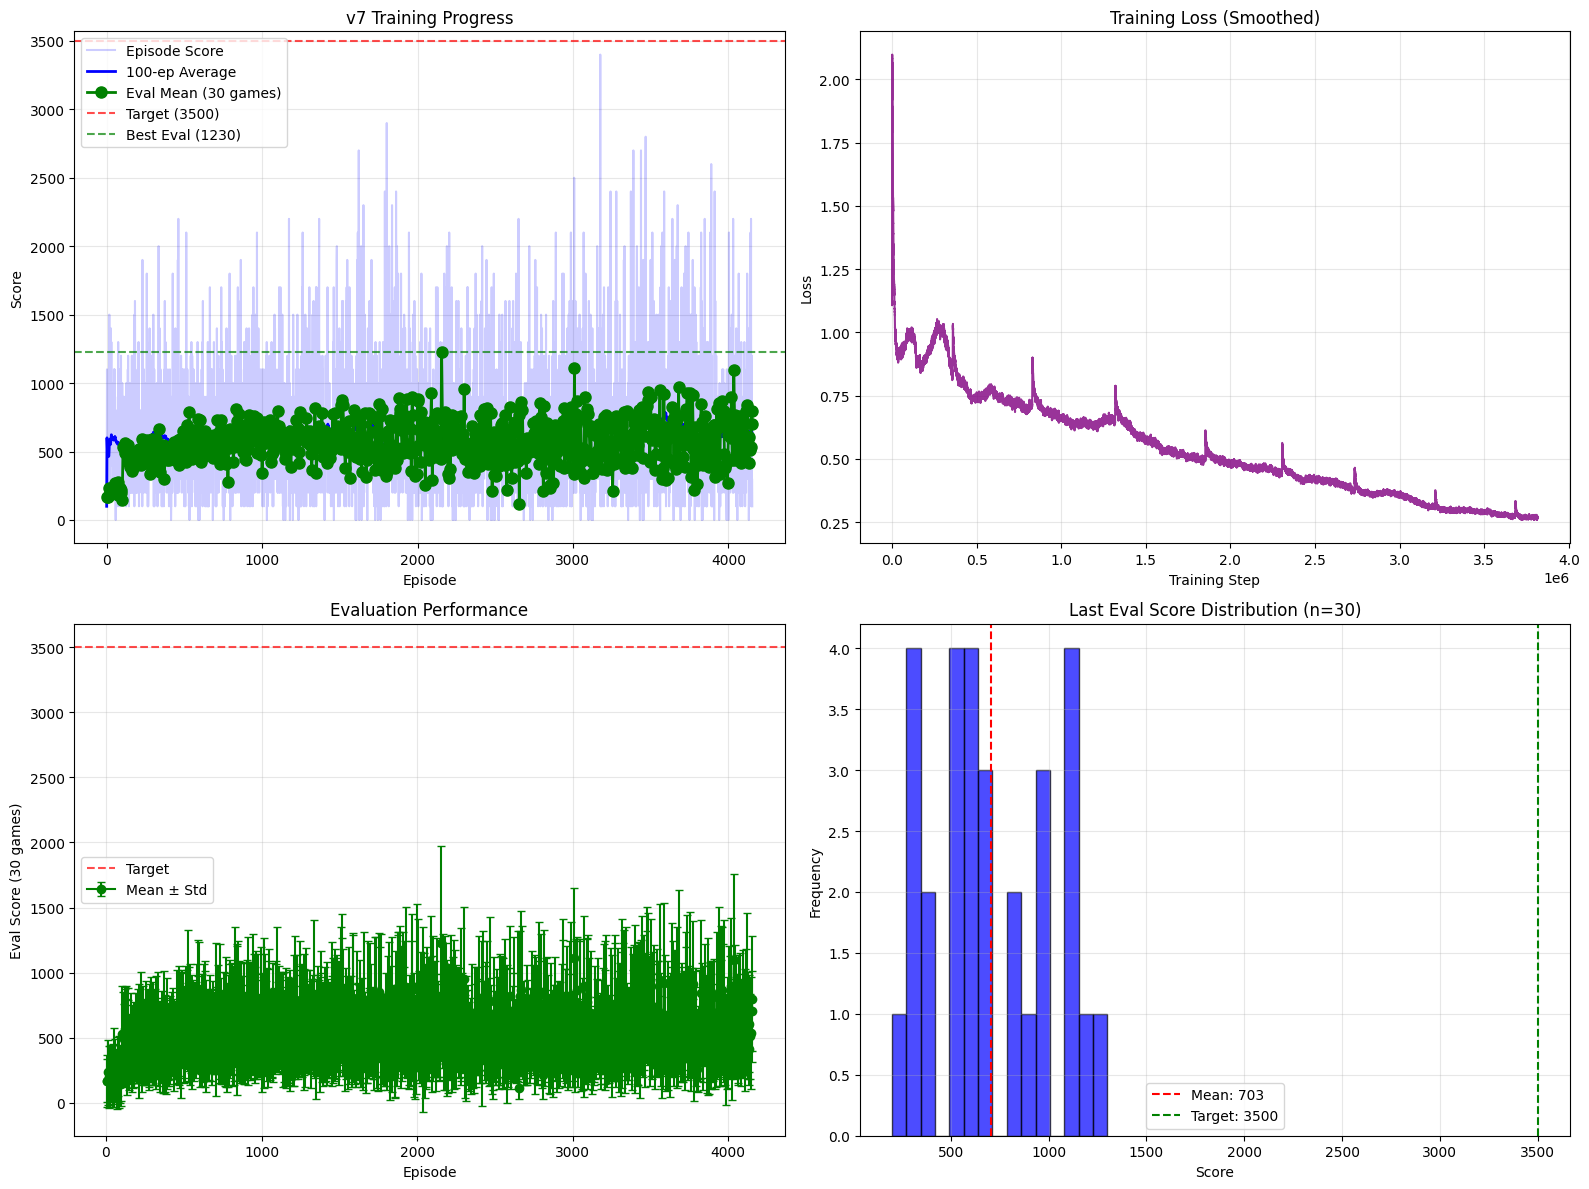

📊 Plot saved: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/v7_simplified_PER_20260118_055120/training_progress_v7.png


In [ ]:
# ============================================================
# 📊 PLOT TRAINING PROGRESS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training scores with eval overlay
ax1 = axes[0, 0]
ax1.plot(training_scores, alpha=0.2, color='blue', label='Episode Score')
ax1.plot(training_avg, color='blue', linewidth=2, label='100-ep Average')

if eval_history:
    eval_eps = [e[0] for e in eval_history]
    eval_means = [e[1]['mean'] for e in eval_history]
    ax1.plot(eval_eps, eval_means, 'go-', markersize=8, linewidth=2, label='Eval Mean (30 games)')

ax1.axhline(y=3500, color='red', linestyle='--', alpha=0.7, label='Target (3500)')
ax1.axhline(y=best_eval_mean, color='green', linestyle='--', alpha=0.7, label=f'Best Eval ({best_eval_mean:.0f})')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Score')
ax1.set_title('v7 Training Progress')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Loss
ax2 = axes[0, 1]
if len(agent.losses) > 0:
    window = min(1000, max(1, len(agent.losses) // 20))
    smoothed = np.convolve(agent.losses, np.ones(window)/window, mode='valid')
    ax2.plot(smoothed, color='purple', alpha=0.8)
ax2.set_xlabel('Training Step')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss (Smoothed)')
ax2.grid(True, alpha=0.3)

# Plot 3: Evaluation history
ax3 = axes[1, 0]
if eval_history:
    eval_eps = [e[0] for e in eval_history]
    eval_means = [e[1]['mean'] for e in eval_history]
    eval_stds = [e[1]['std'] for e in eval_history]

    ax3.errorbar(eval_eps, eval_means, yerr=eval_stds, fmt='o-', capsize=3,
                 color='green', label='Mean ± Std')
    ax3.axhline(y=3500, color='red', linestyle='--', alpha=0.7, label='Target')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Eval Score (30 games)')
    ax3.set_title('Evaluation Performance')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Plot 4: Score distribution (last evaluation)
ax4 = axes[1, 1]
if eval_history:
    last_scores = eval_history[-1][1]['scores']
    ax4.hist(last_scores, bins=15, color='blue', alpha=0.7, edgecolor='black')
    ax4.axvline(x=np.mean(last_scores), color='red', linestyle='--',
                label=f'Mean: {np.mean(last_scores):.0f}')
    ax4.axvline(x=3500, color='green', linestyle='--', label='Target: 3500')
    ax4.set_xlabel('Score')
    ax4.set_ylabel('Frequency')
    ax4.set_title(f'Last Eval Score Distribution (n={len(last_scores)})')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_progress_v7.png", dpi=150)
plt.show()

print(f"📊 Plot saved: {OUTPUT_DIR}/training_progress_v7.png")

---
# 🎬 Record Video

In [ ]:
# ============================================================
# 🎬 RECORD VIDEO WITH BEST MODEL
# ============================================================

# Load best model
best_model_path = f"{OUTPUT_DIR}/models/best_eval_model.pth"
if os.path.exists(best_model_path):
    agent.policy_net.load_state_dict(torch.load(best_model_path, map_location=agent.device))
    print(f"✅ Loaded best_eval_model.pth (ep {best_eval_episode})")
else:
    print(f"⚠️ best_eval_model not found, using final model")

video_path, game_scores = record_gameplay(
    agent,
    output_path=f"{OUTPUT_DIR}/videos/v7_gameplay.mp4",
    num_games=20,
    fps=60
)

print(f"\n🎬 Video ready: {video_path}")
print(f"\n📊 Final Performance (20 games):")
print(f"   Mean: {np.mean(game_scores):.1f} ± {np.std(game_scores):.1f}")
print(f"   Min: {min(game_scores)} | Max: {max(game_scores)}")

✅ Loaded best_eval_model.pth (ep 2155)

🎬 Recording 20 games...
pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
  Game 1/20...
    Score: 2300 | Kills: 23
  Game 2/20...
    Score: 900 | Kills: 9
  Game 3/20...
    Score: 200 | Kills: 2
  Game 4/20...
    Score: 800 | Kills: 8
  Game 5/20...
    Score: 900 | Kills: 9
  Game 6/20...
    Score: 1800 | Kills: 18
  Game 7/20...
    Score: 200 | Kills: 2
  Game 8/20...
    Score: 600 | Kills: 6
  Game 9/20...
    Score: 600 | Kills: 6
  Game 10/20...
    Score: 700 | Kills: 7
  Game 11/20...
    Score: 900 | Kills: 9
  Game 12/20...
    Score: 1000 | Kills: 10
  Game 13/20...
    Score: 800 | Kills: 8
  Game 14/20...
    Score: 800 | Kills: 8
  Game 15/20...
    Score: 2600 | Kills: 26
  Game 16/20...
    Score: 1500 | Kills: 15
  Game 17/20...
    Score: 600 | Kills: 6
  Game 18/20...
    Score: 800 | Kills: 8
  Game 19/20...
    Score: 2000 | Kills: 20
  Game 20/20...
    S

✅ Video saved: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/v7_simplified_PER_20260118_055120/videos/v7_gameplay.mp4

🎬 Video ready: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/v7_simplified_PER_20260118_055120/videos/v7_gameplay.mp4

📊 Final Performance (20 games):
   Mean: 1035.0 ± 642.1
   Min: 200 | Max: 2600


---
# 📁 Summary

In [ ]:
# ============================================================
# 📁 SUMMARY
# ============================================================

print("="*60)
print("📁 v7 TRAINING SUMMARY")
print("="*60)
print(f"\nOutput directory: {OUTPUT_DIR}\n")

for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        if size > 1024 * 1024:
            size_str = f"{size / (1024*1024):.1f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"{subindent}📄 {file} ({size_str})")

print("\n" + "="*60)
print("📊 RESULTS")
print("="*60)
print(f"   Best Eval Mean: {best_eval_mean:.1f}")
print(f"   Best Eval Episode: {best_eval_episode}")
print(f"   Target: 3500 ± 300")
print(f"   Status: {'✅ TARGET REACHED!' if best_eval_mean >= 3200 else '🔄 Continue training or adjust approach'}")
print("="*60)
print("\n🎯 RECOMMENDED: Use best_eval_model.pth")

📁 v7 TRAINING SUMMARY

Output directory: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/v7_simplified_PER_20260118_055120

📂 v7_simplified_PER_20260118_055120/
  📄 best_eval_details.json (616 B)
  📄 training_progress_v7.png (264.3 KB)
  📂 models/
    📄 best_eval_model.pth (1.9 MB)
    📄 checkpoint_ep5.pth (1.9 MB)
    📄 checkpoint_ep10.pth (1.9 MB)
    📄 checkpoint_ep15.pth (1.9 MB)
    📄 checkpoint_ep20.pth (1.9 MB)
    📄 checkpoint_ep25.pth (1.9 MB)
    📄 checkpoint_ep30.pth (1.9 MB)
    📄 checkpoint_ep35.pth (1.9 MB)
    📄 checkpoint_ep40.pth (1.9 MB)
    📄 checkpoint_ep45.pth (1.9 MB)
    📄 checkpoint_ep50.pth (1.9 MB)
    📄 checkpoint_ep55.pth (1.9 MB)
    📄 checkpoint_ep60.pth (1.9 MB)
    📄 checkpoint_ep65.pth (1.9 MB)
    📄 checkpoint_ep70.pth (1.9 MB)
    📄 checkpoint_ep75.pth (1.9 MB)
    📄 checkpoint_ep80.pth (1.9 MB)
    📄 checkpoint_ep85.pth (1.9 MB)
    📄 checkpoint_ep90.pth (1.9 MB)
    📄 checkpoint_ep95.pth (1.9 MB)
    📄 checkpoint_ep100.pth (1.9 MB)
    📄 c

In [ ]:
# Optional: Disconnect runtime
from google.colab import runtime
runtime.unassign()